### Importing the libraries and loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/raw/indian_road_accidents.csv")

df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,10/22/2023,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,5/21/2023,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,7/10/2024,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,3/30/2025,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,1/25/2024,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


### Dataset Inspection

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 20000
Columns: 24


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [4]:
df.describe(include="all")

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
count,20000.000000,20000,20000,20000.000000,20000.000000,20000,20000,20000.000000,20000,20000.000000,...,20000,20000.000000,20000,20000,20000,20000.000000,20000.000000,20000.000000,115,20000.000000
unique,NaN,8,7,NaN,NaN,1201,24,NaN,7,NaN,...,3,NaN,3,5,3,NaN,NaN,NaN,4,NaN
top,NaN,Chandigarh,Maharashtra,NaN,NaN,11/3/2022,2:00,NaN,Monday,NaN,...,low,NaN,low,distraction,minor,NaN,NaN,NaN,Holi,NaN
freq,NaN,2577,5009,NaN,NaN,30,888,NaN,2966,NaN,...,9987,NaN,7067,4026,11025,NaN,NaN,NaN,38,NaN
mean,9999.500000,NaN,NaN,20.389207,78.173330,NaN,NaN,11.487200,NaN,0.286150,...,NaN,27.579600,NaN,NaN,NaN,2.992000,1.726450,0.247400,NaN,0.437585
std,5773.647028,NaN,NaN,6.165791,4.485967,NaN,NaN,6.945563,NaN,0.451972,...,NaN,7.454746,NaN,NaN,NaN,1.415534,1.489104,0.431512,NaN,0.218130
min,0.000000,NaN,NaN,12.800172,72.700017,NaN,NaN,0.000000,NaN,0.000000,...,NaN,15.000000,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,0.100000
25%,4999.750000,NaN,NaN,13.198653,73.997979,NaN,NaN,5.000000,NaN,0.000000,...,NaN,21.000000,NaN,NaN,NaN,2.000000,1.000000,0.000000,NaN,0.250000
50%,9999.500000,NaN,NaN,18.812008,77.297000,NaN,NaN,12.000000,NaN,0.000000,...,NaN,28.000000,NaN,NaN,NaN,3.000000,1.000000,0.000000,NaN,0.450000
75%,14999.250000,NaN,NaN,28.402467,80.111089,NaN,NaN,18.000000,NaN,1.000000,...,NaN,34.000000,NaN,NaN,NaN,4.000000,3.000000,0.000000,NaN,0.600000


In [5]:
df.columns.tolist()

['accident_id',
 'city',
 'state',
 'latitude',
 'longitude',
 'date',
 'time',
 'hour',
 'day_of_week',
 'is_weekend',
 'road_type',
 'lanes',
 'traffic_signal',
 'weather',
 'visibility',
 'temperature',
 'traffic_density',
 'cause',
 'accident_severity',
 'vehicles_involved',
 'casualties',
 'is_peak_hour',
 'festival',
 'risk_score']

### Check Missing Values

In [6]:
missing = df.isnull().sum()

print(missing)

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64


In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage.sort_values(ascending=False))

festival             99.425
accident_id           0.000
state                 0.000
city                  0.000
longitude             0.000
date                  0.000
time                  0.000
latitude              0.000
hour                  0.000
day_of_week           0.000
road_type             0.000
is_weekend            0.000
traffic_signal        0.000
weather               0.000
visibility            0.000
lanes                 0.000
temperature           0.000
traffic_density       0.000
accident_severity     0.000
cause                 0.000
vehicles_involved     0.000
casualties            0.000
is_peak_hour          0.000
risk_score            0.000
dtype: float64


### Check Duplicate Values

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Duplicate accident IDs:", df["accident_id"].duplicated().sum())

Duplicate accident IDs: 0


In [10]:
categorical_columns = [
    "city",
    "state",
    "road_type",
    "traffic_signal",
    "weather",
    "visibility",
    "traffic_density",
    "cause",
    "accident_severity",
    "festival"
]

for column in categorical_columns:
    print("\n", "=" * 50)
    print(column)
    print(df[column].value_counts(dropna=False))


city
city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
Name: count, dtype: int64

state
state
Maharashtra    5009
Punjab         2577
Tamil Nadu     2575
West Bengal    2559
Karnataka      2438
Delhi          2433
Telangana      2409
Name: count, dtype: int64

road_type
road_type
urban      6745
rural      6639
highway    6616
Name: count, dtype: int64

traffic_signal
traffic_signal
0    10003
1     9997
Name: count, dtype: int64

weather
weather
clear    6690
rain     6677
fog      6633
Name: count, dtype: int64

visibility
visibility
low       9987
high      6690
medium    3323
Name: count, dtype: int64

traffic_density
traffic_density
low       7067
high      7034
medium    5899
Name: count, dtype: int64

cause
cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64

accident_severity
acciden

In [11]:
numerical_columns = [
    "latitude",
    "longitude",
    "lanes",
    "temperature",
    "vehicles_involved",
    "casualties",
    "risk_score"
]

df[numerical_columns].describe()

,latitude,longitude,lanes,temperature,vehicles_involved,casualties,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,20.389207,78.173330,3.493950,27.579600,2.992000,1.726450,0.437585
std,6.165791,4.485967,1.705406,7.454746,1.415534,1.489104,0.218130
min,12.800172,72.700017,1.000000,15.000000,1.000000,0.000000,0.100000
25%,13.198653,73.997979,2.000000,21.000000,2.000000,1.000000,0.250000
50%,18.812008,77.297000,4.000000,28.000000,3.000000,1.000000,0.450000
75%,28.402467,80.111089,5.000000,34.000000,4.000000,3.000000,0.600000
max,30.799960,88.499861,6.000000,40.000000,5.000000,5.000000,1.000000


In [12]:
print("Latitude range:")
print(df["latitude"].min(), df["latitude"].max())

print("\nLongitude range:")
print(df["longitude"].min(), df["longitude"].max())

Latitude range:
12.800172 30.79996

Longitude range:
72.700017 88.499861


In [13]:
severity_counts = df["accident_severity"].value_counts()

print(severity_counts)

accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64


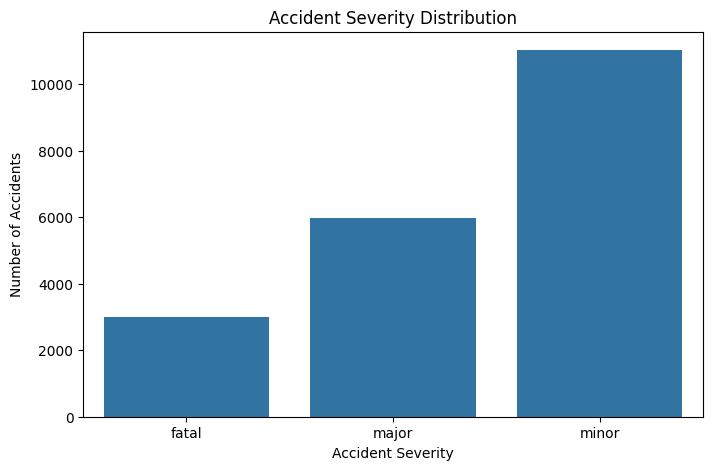

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="accident_severity"
)

plt.title("Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")

plt.show()

In [15]:
df["festival"].value_counts(dropna=False)

festival
NaN         19885
Holi           38
Eid            34
Diwali         31
New Year       12
Name: count, dtype: int64

In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
print("Duplicate accident IDs:", df["accident_id"].duplicated().sum())

Duplicate accident IDs: 0


In [18]:
categorical_columns = [
    "city",
    "state",
    "road_type",
    "traffic_signal",
    "weather",
    "visibility",
    "traffic_density",
    "cause",
    "accident_severity",
    "festival"
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column)
    print("=" * 50)
    print(df[column].value_counts(dropna=False))


city
city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
Name: count, dtype: int64

state
state
Maharashtra    5009
Punjab         2577
Tamil Nadu     2575
West Bengal    2559
Karnataka      2438
Delhi          2433
Telangana      2409
Name: count, dtype: int64

road_type
road_type
urban      6745
rural      6639
highway    6616
Name: count, dtype: int64

traffic_signal
traffic_signal
0    10003
1     9997
Name: count, dtype: int64

weather
weather
clear    6690
rain     6677
fog      6633
Name: count, dtype: int64

visibility
visibility
low       9987
high      6690
medium    3323
Name: count, dtype: int64

traffic_density
traffic_density
low       7067
high      7034
medium    5899
Name: count, dtype: int64

cause
cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64

accident_severity
acciden

In [19]:
numerical_columns = [
    "latitude",
    "longitude",
    "hour",
    "lanes",
    "temperature",
    "vehicles_involved",
    "casualties",
    "risk_score"
]

df[numerical_columns].describe()

,latitude,longitude,hour,lanes,temperature,vehicles_involved,casualties,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,20.389207,78.173330,11.487200,3.493950,27.579600,2.992000,1.726450,0.437585
std,6.165791,4.485967,6.945563,1.705406,7.454746,1.415534,1.489104,0.218130
min,12.800172,72.700017,0.000000,1.000000,15.000000,1.000000,0.000000,0.100000
25%,13.198653,73.997979,5.000000,2.000000,21.000000,2.000000,1.000000,0.250000
50%,18.812008,77.297000,12.000000,4.000000,28.000000,3.000000,1.000000,0.450000
75%,28.402467,80.111089,18.000000,5.000000,34.000000,4.000000,3.000000,0.600000
max,30.799960,88.499861,23.000000,6.000000,40.000000,5.000000,5.000000,1.000000


In [20]:
print("Latitude range:")
print(df["latitude"].min(), df["latitude"].max())

print("\nLongitude range:")
print(df["longitude"].min(), df["longitude"].max())

Latitude range:
12.800172 30.79996

Longitude range:
72.700017 88.499861


In [21]:
print("Invalid latitude:",
      ((df["latitude"] < 6) | (df["latitude"] > 37)).sum())

print("Invalid longitude:",
      ((df["longitude"] < 68) | (df["longitude"] > 98)).sum())

Invalid latitude: 0
Invalid longitude: 0


In [22]:
print("Unique lanes:")
print(sorted(df["lanes"].unique()))

print("\nUnique vehicles involved:")
print(sorted(df["vehicles_involved"].unique()))

print("\nUnique casualties:")
print(sorted(df["casualties"].unique()))

Unique lanes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Unique vehicles involved:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Unique casualties:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


### Visualization 1 — Accident Severity

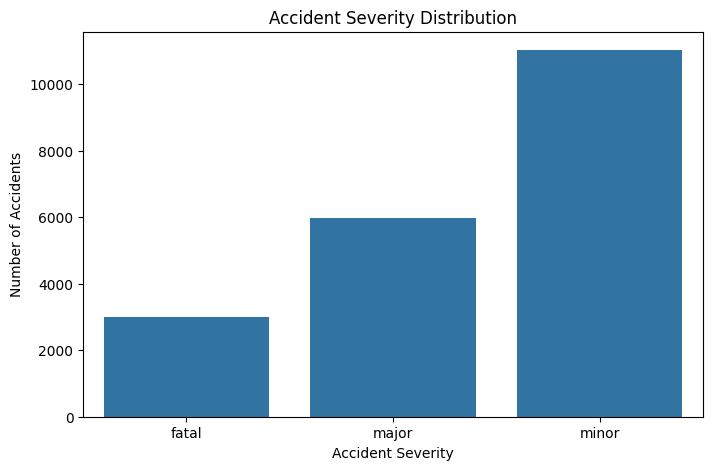

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="accident_severity"
)

plt.title("Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")

plt.show()

### Visualization 2 — Accidents by City

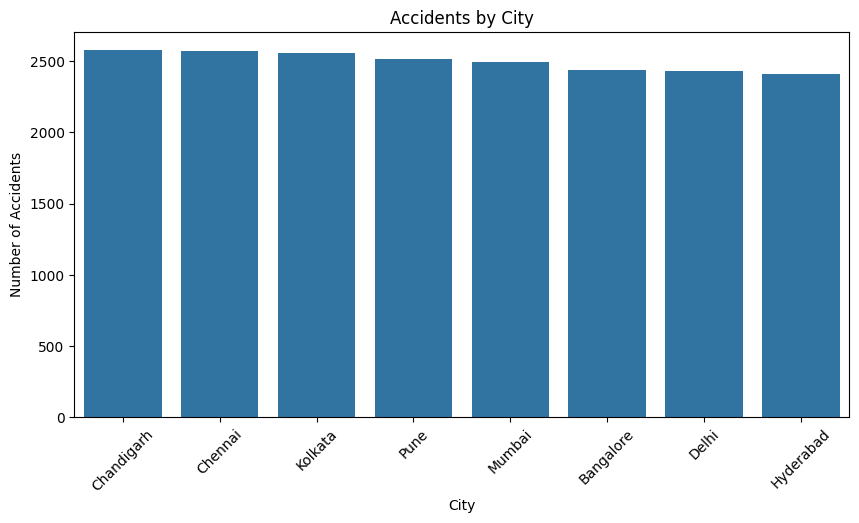

In [24]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="city",
    order=df["city"].value_counts().index
)

plt.title("Accidents by City")
plt.xlabel("City")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.show()

### Visualization 3 — Accidents by Cause

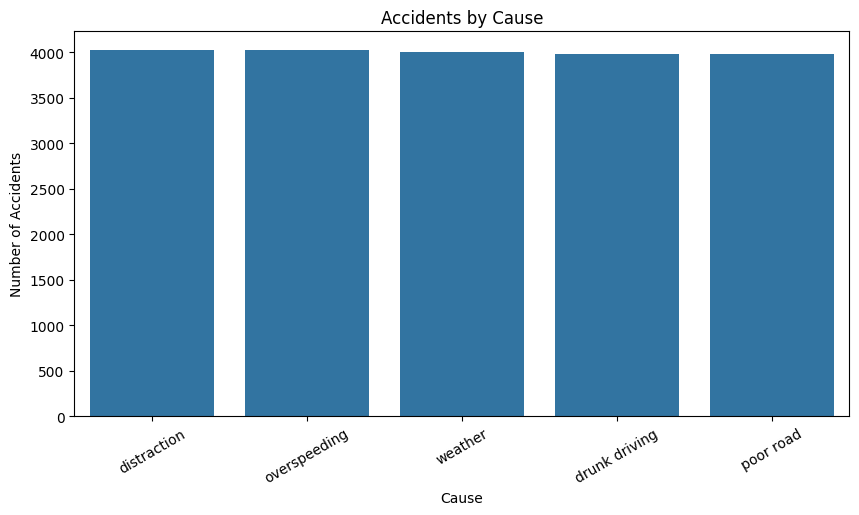

In [25]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="cause",
    order=df["cause"].value_counts().index
)

plt.title("Accidents by Cause")
plt.xlabel("Cause")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)

plt.show()

### Visualization 4 — Accidents by Weather

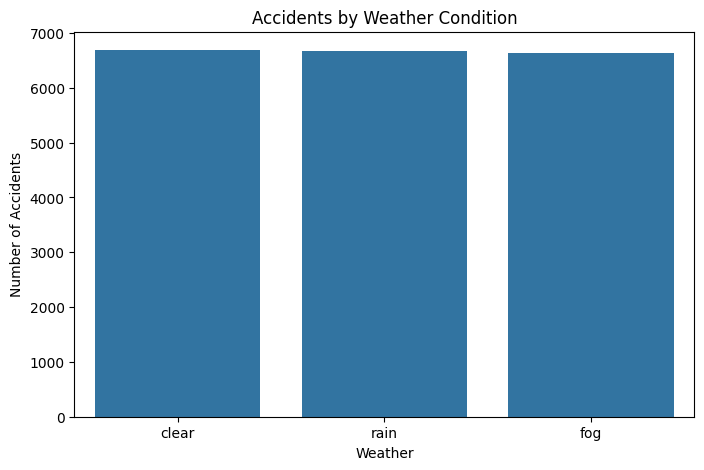

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="weather",
    order=df["weather"].value_counts().index
)

plt.title("Accidents by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")

plt.show()

### Analysis 1 — Weather vs Accident Severity

In [27]:
weather_severity = pd.crosstab(
    df["weather"],
    df["accident_severity"]
)

print(weather_severity)

accident_severity  fatal  major  minor
weather                               
clear                992   2017   3681
fog                  995   1975   3663
rain                1000   1996   3681


In [28]:
weather_severity_pct = pd.crosstab(
    df["weather"],
    df["accident_severity"],
    normalize="index"
) * 100

print(weather_severity_pct.round(2))

accident_severity  fatal  major  minor
weather                               
clear              14.83  30.15  55.02
fog                15.00  29.78  55.22
rain               14.98  29.89  55.13


The severity distribution is almost identical across all three weather conditions.
So we cannot claim that fog or rain causes more severe accidents based on this dataset.
And this is actually a valuable finding.

So, Weather appears to have very little relationship with accident severity in this dataset.

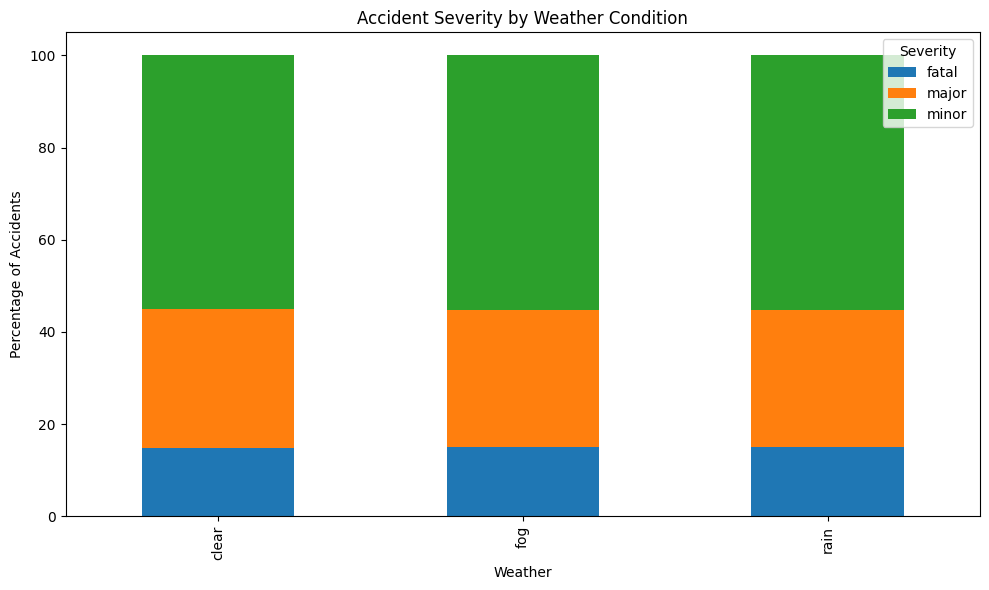

In [29]:
weather_severity_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Accident Severity by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Percentage of Accidents")
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

### Analysis 2 — Cause × Severity

In [30]:
cause_severity = pd.crosstab(
    df["cause"],
    df["accident_severity"]
)

print(cause_severity)

accident_severity  fatal  major  minor
cause                                 
distraction          542   1244   2240
drunk driving        618   1164   2196
overspeeding         603   1203   2219
poor road            623   1172   2179
weather              601   1205   2191


In [31]:
cause_severity_pct = pd.crosstab(
    df["cause"],
    df["accident_severity"],
    normalize="index"
) * 100

print(cause_severity_pct.round(2))

accident_severity  fatal  major  minor
cause                                 
distraction        13.46  30.90  55.64
drunk driving      15.54  29.26  55.20
overspeeding       14.98  29.89  55.13
poor road          15.68  29.49  54.83
weather            15.04  30.15  54.82


Accident severity proportions are relatively similar across the five recorded causes in this dataset.

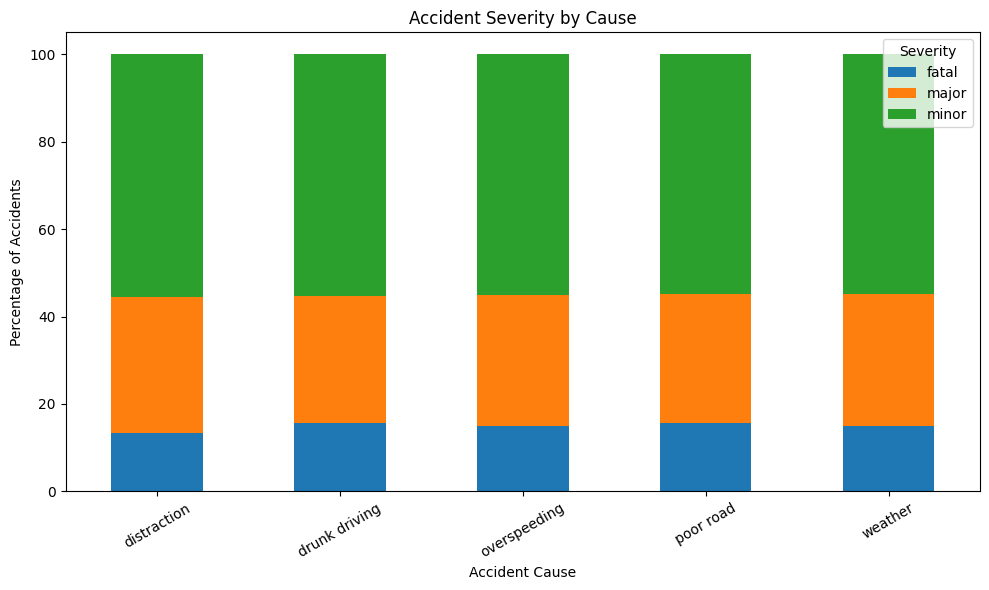

In [32]:
cause_severity_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Accident Severity by Cause")
plt.xlabel("Accident Cause")
plt.ylabel("Percentage of Accidents")
plt.legend(title="Severity")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Analysis 3 — Road Type × Severity

In [33]:
road_severity_pct = pd.crosstab(
    df["road_type"],
    df["accident_severity"],
    normalize="index"
) * 100

print(road_severity_pct.round(2))

accident_severity  fatal  major  minor
road_type                             
highway            14.86  29.73  55.41
rural              14.54  30.34  55.13
urban              15.40  29.76  54.84


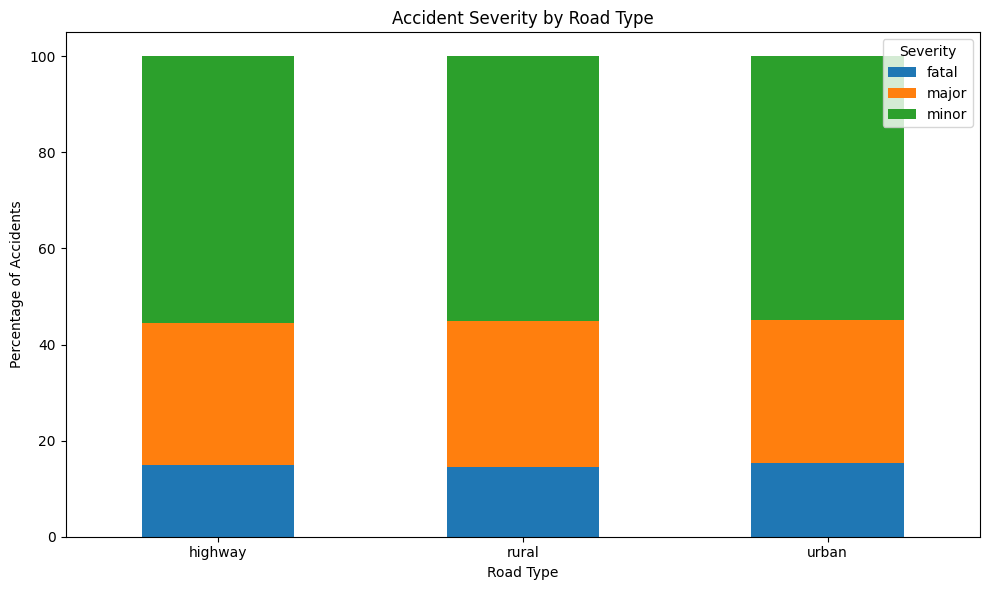

In [34]:
road_severity_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Accident Severity by Road Type")
plt.xlabel("Road Type")
plt.ylabel("Percentage of Accidents")
plt.legend(title="Severity")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analysis 4 — Traffic Density × Severity

In [35]:
traffic_severity_pct = pd.crosstab(
    df["traffic_density"],
    df["accident_severity"],
    normalize="index"
) * 100

print(traffic_severity_pct.round(2))

accident_severity  fatal  major  minor
traffic_density                       
high               14.86  29.53  55.62
low                15.01  29.94  55.04
medium             14.93  30.43  54.64


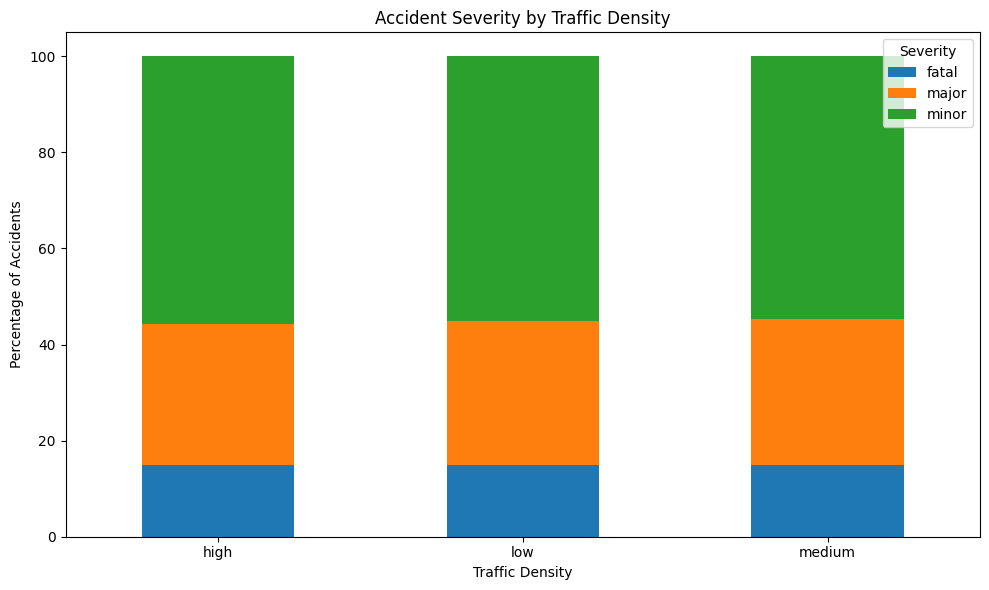

In [36]:
traffic_severity_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Accident Severity by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Percentage of Accidents")
plt.legend(title="Severity")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Vehicles Involved × Severity

In [37]:
vehicle_severity = pd.crosstab(
    df["vehicles_involved"],
    df["accident_severity"],
    normalize="index"
) * 100

print(vehicle_severity.round(2))

accident_severity  fatal  major  minor
vehicles_involved                     
1                  14.81  30.92  54.27
2                  14.99  29.31  55.71
3                  14.47  30.52  55.00
4                  15.47  29.80  54.73
5                  14.94  29.15  55.92


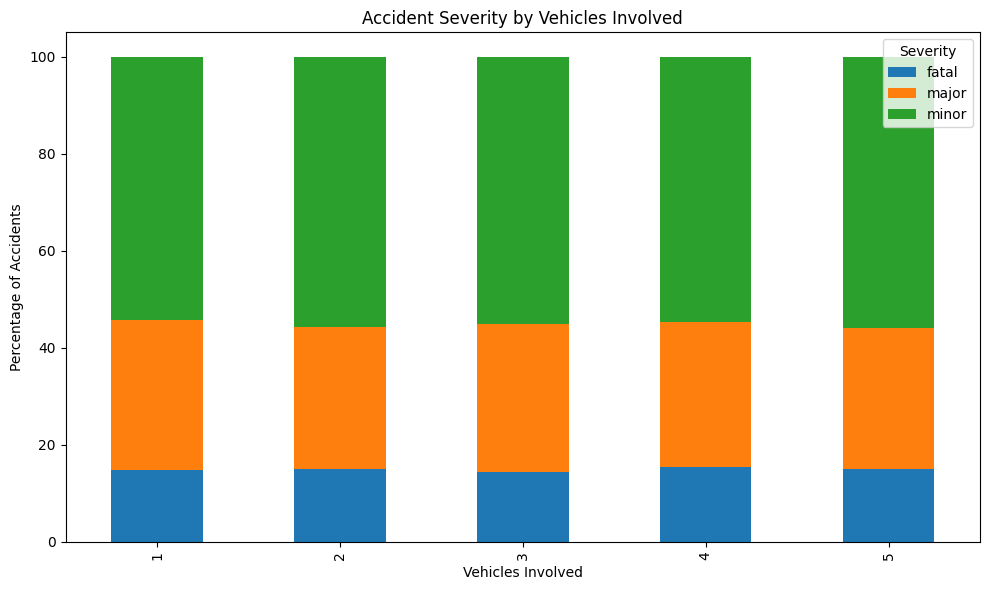

In [38]:
vehicle_severity.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Accident Severity by Vehicles Involved")
plt.xlabel("Vehicles Involved")
plt.ylabel("Percentage of Accidents")
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

### Casualties × Severity

In [39]:
casualty_severity = pd.crosstab(
    df["casualties"],
    df["accident_severity"],
    normalize="index"
) * 100

print(casualty_severity.round(2))

accident_severity  fatal  major  minor
casualties                            
0                   0.00  35.03  64.97
1                  10.83  32.01  57.16
2                  15.61  29.31  55.08
3                  21.67  27.13  51.20
4                  33.04  24.63  42.32
5                  50.77  15.73  33.50


Higher casualty counts are strongly associated with higher accident severity.


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [41]:
print(df.dtypes)

accident_id            int64
city                  object
state                 object
latitude             float64
longitude            float64
date                  object
time                  object
hour                   int64
day_of_week           object
is_weekend             int64
road_type             object
lanes                  int64
traffic_signal         int64
weather               object
visibility            object
temperature            int64
traffic_density       object
cause                 object
accident_severity     object
vehicles_involved      int64
casualties             int64
is_peak_hour           int64
festival              object
risk_score           float64
dtype: object


### Check the binary columns

In [42]:
print("traffic_signal:")
print(df["traffic_signal"].unique())

print("\nis_weekend:")
print(df["is_weekend"].unique())

print("\nis_peak_hour:")
print(df["is_peak_hour"].unique())

traffic_signal:
[1 0]

is_weekend:
[1 0]

is_peak_hour:
[0 1]


### Check date and time

In [43]:
print("Date examples:")
print(df["date"].head())

print("\nTime examples:")
print(df["time"].head())

Date examples:
0    10/22/2023
1     5/21/2023
2     7/10/2024
3     3/30/2025
4     1/25/2024
Name: date, dtype: object

Time examples:
0     5:00
1     4:00
2    13:00
3    11:00
4    16:00
Name: time, dtype: object


In [44]:
print("\nDate data type:", df["date"].dtype)
print("Time data type:", df["time"].dtype)


Date data type: object
Time data type: object


### Clean festival

In [45]:
df["festival"] = df["festival"].fillna("No Festival")

### Create a separate cleaned DataFrame

In [46]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Cleaned dataframe shape:", df_clean.shape)

Original shape: (20000, 24)
Cleaned dataframe shape: (20000, 24)


### Convert the date

In [47]:
df_clean["date"] = pd.to_datetime(
    df_clean["date"],
    format="%m/%d/%Y",
    errors="coerce"
)

In [48]:
print("Invalid dates:", df_clean["date"].isna().sum())

Invalid dates: 0


### Convert the time

In [49]:
df_clean["time"] = pd.to_datetime(
    df_clean["time"],
    format="%H:%M",
    errors="coerce"
)

In [50]:
print("Invalid times:", df_clean["time"].isna().sum())

Invalid times: 0


### Create a proper accident datetime

In [51]:
df_clean["datetime"] = pd.to_datetime(
    df_clean["date"].dt.strftime("%Y-%m-%d") + " " +
    df_clean["time"].dt.strftime("%H:%M:%S"),
    errors="coerce"
)

In [52]:
print("Invalid datetime:", df_clean["datetime"].isna().sum())

Invalid datetime: 0


### Handle festival

In [53]:
df_clean["festival"] = df_clean["festival"].fillna("No Festival")

In [54]:
print(df_clean["festival"].value_counts())

festival
No Festival    19885
Holi              38
Eid               34
Diwali            31
New Year          12
Name: count, dtype: int64


### Create useful time features

In [55]:
df_clean["year"] = df_clean["date"].dt.year

In [56]:
df_clean["month"] = df_clean["date"].dt.month

In [57]:
df_clean["month_name"] = df_clean["date"].dt.month_name()

In [58]:
df_clean["quarter"] = df_clean["date"].dt.quarter

In [59]:
df_clean["day"] = df_clean["date"].dt.day

### Create a time period

In [60]:
def get_time_period(hour):
    if 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 20:
        return "Evening"
    else:
        return "Night"

df_clean["time_period"] = df_clean["hour"].apply(get_time_period)

In [61]:
print(df_clean["time_period"].value_counts())

time_period
Night        7551
Morning      4907
Afternoon    4180
Evening      3362
Name: count, dtype: int64


### Create a severe accident indicator

In [62]:
df_clean["is_severe"] = (
    df_clean["accident_severity"]
    .isin(["fatal", "major"])
    .astype(int)
)

In [63]:
print(df_clean["is_severe"].value_counts())

is_severe
0    11025
1     8975
Name: count, dtype: int64


### Create fatal indicator

In [64]:
df_clean["is_fatal"] = (
    df_clean["accident_severity"] == "fatal"
).astype(int)

### Check our cleaned dataset

In [65]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   accident_id        20000 non-null  int64         
 1   city               20000 non-null  object        
 2   state              20000 non-null  object        
 3   latitude           20000 non-null  float64       
 4   longitude          20000 non-null  float64       
 5   date               20000 non-null  datetime64[ns]
 6   time               20000 non-null  datetime64[ns]
 7   hour               20000 non-null  int64         
 8   day_of_week        20000 non-null  object        
 9   is_weekend         20000 non-null  int64         
 10  road_type          20000 non-null  object        
 11  lanes              20000 non-null  int64         
 12  traffic_signal     20000 non-null  int64         
 13  weather            20000 non-null  object        
 14  visibi

In [66]:
print(df_clean.head())

   accident_id        city        state   latitude  longitude       date  \
0            0        Pune  Maharashtra  18.680827  73.930388 2023-10-22   
1            1      Mumbai  Maharashtra  18.817732  72.790846 2023-05-21   
2            2      Mumbai  Maharashtra  19.096889  72.819424 2024-07-10   
3            3  Chandigarh       Punjab  30.787805  76.847507 2025-03-30   
4            4     Chennai   Tamil Nadu  12.965155  80.283313 2024-01-25   

                 time  hour day_of_week  is_weekend  ... risk_score  \
0 1900-01-01 05:00:00     5      Sunday           1  ...       0.85   
1 1900-01-01 04:00:00     4      Sunday           1  ...       0.10   
2 1900-01-01 13:00:00    13   Wednesday           0  ...       0.45   
3 1900-01-01 11:00:00    11      Sunday           1  ...       0.65   
4 1900-01-01 16:00:00    16    Thursday           0  ...       0.10   

             datetime  year month month_name  quarter day time_period  \
0 2023-10-22 05:00:00  2023    10    Octobe

In [67]:
print("Final shape:", df_clean.shape)

Final shape: (20000, 33)


In [68]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   accident_id        20000 non-null  int64         
 1   city               20000 non-null  object        
 2   state              20000 non-null  object        
 3   latitude           20000 non-null  float64       
 4   longitude          20000 non-null  float64       
 5   date               20000 non-null  datetime64[ns]
 6   time               20000 non-null  datetime64[ns]
 7   hour               20000 non-null  int64         
 8   day_of_week        20000 non-null  object        
 9   is_weekend         20000 non-null  int64         
 10  road_type          20000 non-null  object        
 11  lanes              20000 non-null  int64         
 12  traffic_signal     20000 non-null  int64         
 13  weather            20000 non-null  object        
 14  visibi

In [69]:
print(df_clean["time_period"].value_counts())
print(df_clean["is_severe"].value_counts())

time_period
Night        7551
Morning      4907
Afternoon    4180
Evening      3362
Name: count, dtype: int64
is_severe
0    11025
1     8975
Name: count, dtype: int64


In [70]:
df_clean["time"] = df_clean["time"].dt.strftime("%H:%M")

In [71]:
print(df_clean[["date", "time", "datetime"]].head())

        date   time            datetime
0 2023-10-22  05:00 2023-10-22 05:00:00
1 2023-05-21  04:00 2023-05-21 04:00:00
2 2024-07-10  13:00 2024-07-10 13:00:00
3 2025-03-30  11:00 2025-03-30 11:00:00
4 2024-01-25  16:00 2024-01-25 16:00:00


In [72]:
casualty_severity = pd.crosstab(
    df_clean["casualties"],
    df_clean["accident_severity"],
    normalize="index"
) * 100

print(casualty_severity.round(2))

accident_severity  fatal  major  minor
casualties                            
0                   0.00  35.03  64.97
1                  10.83  32.01  57.16
2                  15.61  29.31  55.08
3                  21.67  27.13  51.20
4                  33.04  24.63  42.32
5                  50.77  15.73  33.50


In [73]:
vehicle_severity = pd.crosstab(
    df_clean["vehicles_involved"],
    df_clean["accident_severity"],
    normalize="index"
) * 100

print(vehicle_severity.round(2))

accident_severity  fatal  major  minor
vehicles_involved                     
1                  14.81  30.92  54.27
2                  14.99  29.31  55.71
3                  14.47  30.52  55.00
4                  15.47  29.80  54.73
5                  14.94  29.15  55.92


In [74]:
df_clean["risk_band"] = pd.cut(
    df_clean["risk_score"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    include_lowest=True
)

In [75]:
risk_severity = pd.crosstab(
    df_clean["risk_band"],
    df_clean["accident_severity"],
    normalize="index"
) * 100

print(risk_severity.round(2))

accident_severity  fatal  major  minor
risk_band                             
Very Low            0.00  35.08  64.92
Low                13.08  31.03  55.89
Medium              8.31  32.36  59.33
High               29.67  24.25  46.08
Very High          97.95   0.74   1.30


In [76]:
print(df_clean["accident_severity"].value_counts())

accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64


In [77]:
print(df_clean[[
    "city",
    "state",
    "road_type",
    "weather",
    "visibility",
    "traffic_density",
    "cause",
    "day_of_week",
    "festival"
]].nunique())

city               8
state              7
road_type          3
weather            3
visibility         3
traffic_density    3
cause              5
day_of_week        7
festival           5
dtype: int64


## RoadSense AI - ML Preparation

### Create the ML dataset

In [78]:
ml_features = [
    "city",
    "state",
    "latitude",
    "longitude",
    "hour",
    "day_of_week",
    "is_weekend",
    "road_type",
    "lanes",
    "traffic_signal",
    "weather",
    "visibility",
    "temperature",
    "traffic_density",
    "cause",
    "vehicles_involved",
    "is_peak_hour",
    "festival"
]

X = df_clean[ml_features]
y = df_clean["accident_severity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 18)
y shape: (20000,)


In [79]:
print(X.head())

         city        state   latitude  longitude  hour day_of_week  \
0        Pune  Maharashtra  18.680827  73.930388     5      Sunday   
1      Mumbai  Maharashtra  18.817732  72.790846     4      Sunday   
2      Mumbai  Maharashtra  19.096889  72.819424    13   Wednesday   
3  Chandigarh       Punjab  30.787805  76.847507    11      Sunday   
4     Chennai   Tamil Nadu  12.965155  80.283313    16    Thursday   

   is_weekend road_type  lanes  traffic_signal weather visibility  \
0           1   highway      3               1     fog        low   
1           1     urban      4               0   clear       high   
2           0     urban      3               0     fog        low   
3           1     urban      1               1     fog        low   
4           0   highway      3               1   clear       high   

   temperature traffic_density        cause  vehicles_involved  is_peak_hour  \
0           32            high      weather                  2             0   
1   

In [80]:
print("\nMissing values:")
print(X.isnull().sum().sum())


Missing values:
0


### Train/Test Split 80% training 20% testing

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


### Verify class distribution

In [82]:
print("Training distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training distribution:
accident_severity
minor    8820
major    4790
fatal    2390
Name: count, dtype: int64

Testing distribution:
accident_severity
minor    2205
major    1198
fatal     597
Name: count, dtype: int64


### Identify categorical and numerical features using One-Hot encoding


In [83]:
categorical_features = [
    "city",
    "state",
    "day_of_week",
    "road_type",
    "weather",
    "visibility",
    "traffic_density",
    "cause",
    "festival"
]

numerical_features = [
    "latitude",
    "longitude",
    "hour",
    "is_weekend",
    "lanes",
    "traffic_signal",
    "temperature",
    "vehicles_involved",
    "is_peak_hour"
]

### Create preprocessing pipeline

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

### First model: Logistic Regression

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [86]:
logistic_model.fit(X_train, y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [87]:
y_pred_lr = logistic_model.predict(X_test)

### Evaluation

In [88]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.55125

Classification Report:
              precision    recall  f1-score   support

       fatal       0.38      0.01      0.01       597
       major       1.00      0.00      0.00      1198
       minor       0.55      1.00      0.71      2205

    accuracy                           0.55      4000
   macro avg       0.64      0.33      0.24      4000
weighted avg       0.66      0.55      0.39      4000



In [89]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

print("Dummy Accuracy:")
print(accuracy_score(y_test, y_pred_dummy))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dummy))

Dummy Accuracy:
0.55125

Classification Report:
              precision    recall  f1-score   support

       fatal       0.00      0.00      0.00       597
       major       0.00      0.00      0.00      1198
       minor       0.55      1.00      0.71      2205

    accuracy                           0.55      4000
   macro avg       0.18      0.33      0.24      4000
weighted avg       0.30      0.55      0.39      4000



c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [90]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

In [91]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [92]:
y_pred_rf = rf_model.predict(X_test)

In [93]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.543

Classification Report:
              precision    recall  f1-score   support

       fatal       0.00      0.00      0.00       597
       major       0.32      0.03      0.06      1198
       minor       0.55      0.97      0.70      2205

    accuracy                           0.54      4000
   macro avg       0.29      0.33      0.25      4000
weighted avg       0.40      0.54      0.40      4000



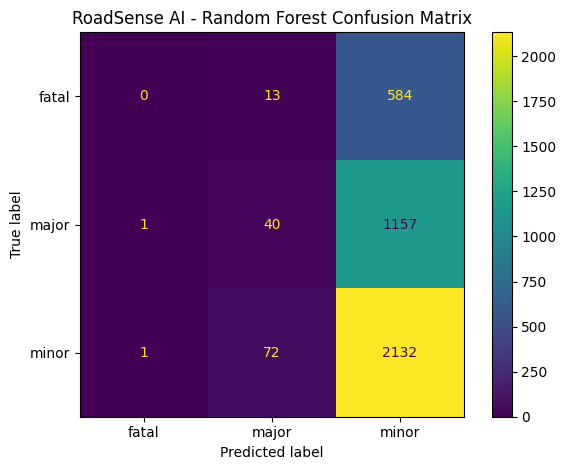

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("RoadSense AI - Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [95]:
from scipy.stats import chi2_contingency
import numpy as np
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    
    phi2 = chi2 / n
    r, k = table.shape
    
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(
        phi2corr / min(kcorr - 1, rcorr - 1)
    )

In [96]:
categorical_columns = [
    "city",
    "state",
    "day_of_week",
    "road_type",
    "weather",
    "visibility",
    "traffic_density",
    "cause",
    "festival"
]

results = []

for col in categorical_columns:
    value = cramers_v(
        df_clean[col],
        df_clean["accident_severity"]
    )
    
    results.append({
        "Feature": col,
        "Cramers_V": value
    })

association_df = pd.DataFrame(results)

print(
    association_df
    .sort_values("Cramers_V", ascending=False)
    .round(3)
)

           Feature  Cramers_V
8         festival      0.017
0             city      0.010
7            cause      0.008
1            state      0.002
2      day_of_week      0.000
4          weather      0.000
3        road_type      0.000
6  traffic_density      0.000
5       visibility      0.000


In [97]:
numeric_columns = [
    "latitude",
    "longitude",
    "hour",
    "is_weekend",
    "lanes",
    "traffic_signal",
    "temperature",
    "vehicles_involved",
    "is_peak_hour"
]

In [98]:
severity_mapping = {
    "minor": 0,
    "major": 1,
    "fatal": 2
}

df_clean["severity_encoded"] = (
    df_clean["accident_severity"]
    .map(severity_mapping)
)

In [99]:
correlation = (
    df_clean[numeric_columns + ["severity_encoded"]]
    .corr()["severity_encoded"]
    .drop("severity_encoded")
    .sort_values(key=abs, ascending=False)
)

print(correlation.round(3))

temperature          0.012
longitude           -0.010
traffic_signal      -0.009
hour                 0.009
lanes                0.007
is_peak_hour         0.004
vehicles_involved   -0.003
latitude            -0.003
is_weekend          -0.002
Name: severity_encoded, dtype: float64


In [100]:
print(df_clean["risk_score"].describe())

count    20000.000000
mean         0.437585
std          0.218130
min          0.100000
25%          0.250000
50%          0.450000
75%          0.600000
max          1.000000
Name: risk_score, dtype: float64


In [101]:
print(df_clean["risk_score"].value_counts().sort_index())

risk_score
0.10    3149
0.20      12
0.25    2111
0.30    1664
0.35       7
0.40     269
0.45    6421
0.50     212
0.55      41
0.60    1304
0.65    2740
0.70       6
0.75      19
0.80    1508
0.85     298
0.90      11
0.95       1
1.00     227
Name: count, dtype: int64


In [102]:
print(
    df_clean[
        ["risk_score", "casualties", "vehicles_involved", "accident_severity"]
    ].corr(numeric_only=True)
)

                   risk_score  casualties  vehicles_involved
risk_score           1.000000    0.119954           0.000642
casualties           0.119954    1.000000           0.550966
vehicles_involved    0.000642    0.550966           1.000000


In [103]:
categorical_columns = [
    "city",
    "state",
    "day_of_week",
    "road_type",
    "weather",
    "visibility",
    "traffic_density",
    "cause",
    "festival"
]

results = []

for col in categorical_columns:
    value = cramers_v(
        df_clean[col],
        df_clean["accident_severity"]
    )

    results.append({
        "Feature": col,
        "Cramers_V": value
    })

association_df = pd.DataFrame(results)

print(
    association_df
    .sort_values("Cramers_V", ascending=False)
    .round(3)
)

           Feature  Cramers_V
8         festival      0.017
0             city      0.010
7            cause      0.008
1            state      0.002
2      day_of_week      0.000
4          weather      0.000
3        road_type      0.000
6  traffic_density      0.000
5       visibility      0.000


In [104]:
import pandas as pd

# ==========================================
# ROAD SENSE AI - CLEAN DATASET
# ==========================================

# 1. Handle missing festival values
df["festival"] = df["festival"].fillna("No Festival")


# 2. Convert date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")


# 3. Convert time to datetime
df["time"] = pd.to_datetime(
    df["time"],
    format="%H:%M",
    errors="coerce"
)


# 4. Create combined datetime
df["datetime"] = (
    df["date"].dt.normalize()
    + (df["time"] - df["time"].dt.normalize())
)


# 5. Create date-based features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["quarter"] = df["date"].dt.quarter
df["day"] = df["date"].dt.day


# 6. Create time-period feature
def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_period"] = df["hour"].apply(get_time_period)


# 7. Create severity-related analytical features
df["is_severe"] = (
    df["accident_severity"] != "minor"
).astype(int)

df["is_fatal"] = (
    df["accident_severity"] == "fatal"
).astype(int)


# 8. Create risk bands from existing risk score
def get_risk_band(score):
    if score < 0.20:
        return "Very Low"
    elif score < 0.40:
        return "Low"
    elif score < 0.60:
        return "Medium"
    elif score < 0.80:
        return "High"
    else:
        return "Very High"

df["risk_band"] = df["risk_score"].apply(get_risk_band)


# ==========================================
# FINAL VALIDATION
# ==========================================

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate accident IDs:")
print(df["accident_id"].duplicated().sum())

print("\nDate type:")
print(df["date"].dtype)

print("\nTime type:")
print(df["time"].dtype)

print("\nRisk bands:")
print(df["risk_band"].value_counts())


# ==========================================
# SAVE CLEAN DATASET
# ==========================================

import os

# Create cleaned dataset folder if it doesn't exist
os.makedirs("../datasets/cleaned", exist_ok=True)

# Save cleaned dataset

df.to_csv(
    "../dataset/cleaned/roadsense_ai_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")


Shape: (20000, 34)

Missing values:
0

Duplicate accident IDs:
0

Date type:
datetime64[ns]

Time type:
datetime64[ns]

Risk bands:
risk_band
Medium       6943
High         4069
Low          3794
Very Low     3149
Very High    2045
Name: count, dtype: int64
Cleaned dataset saved successfully!
